# 1. Image denoising to reduce noise and enhance image quality

## This part of the code uses pretzel noise to add noise to the image (SPN:0.01) and a trof filter to denoise the image for the image denoising step.

**Judging from the visual effects of the images provided in the paper "EMDS - 6: Environmental Microorganism Image Dataset Sixth Version for Image Denoising, Segmentation, Feature Extraction, Classification, and Detection Method Evaluation", the TROF filter performs relatively well**

**In terms of noise removal**

The original noisy image (SPN: 0.01) is full of noise points. In the image filtered by the TROF filter, the noise points have been effectively suppressed, and the overall image becomes smooth and clean, with almost no obvious residual noise points. For the images processed by filters such as GMF and MinF, there are still relatively many noise points, indicating that the noise removal is not thorough enough.
**In terms of image detail preservation**

After being filtered by the TROF filter, the circular target in the center of the image and the surrounding details (such as the radial lines) are relatively well - preserved, and the edges do not show excessive blurring or loss. In contrast, although some filters (such as MF (5×5)) can remove some noise, the overall image shows a blurring effect, indicating that during the noise removal process, excessive smoothing leads to the damage of image details.
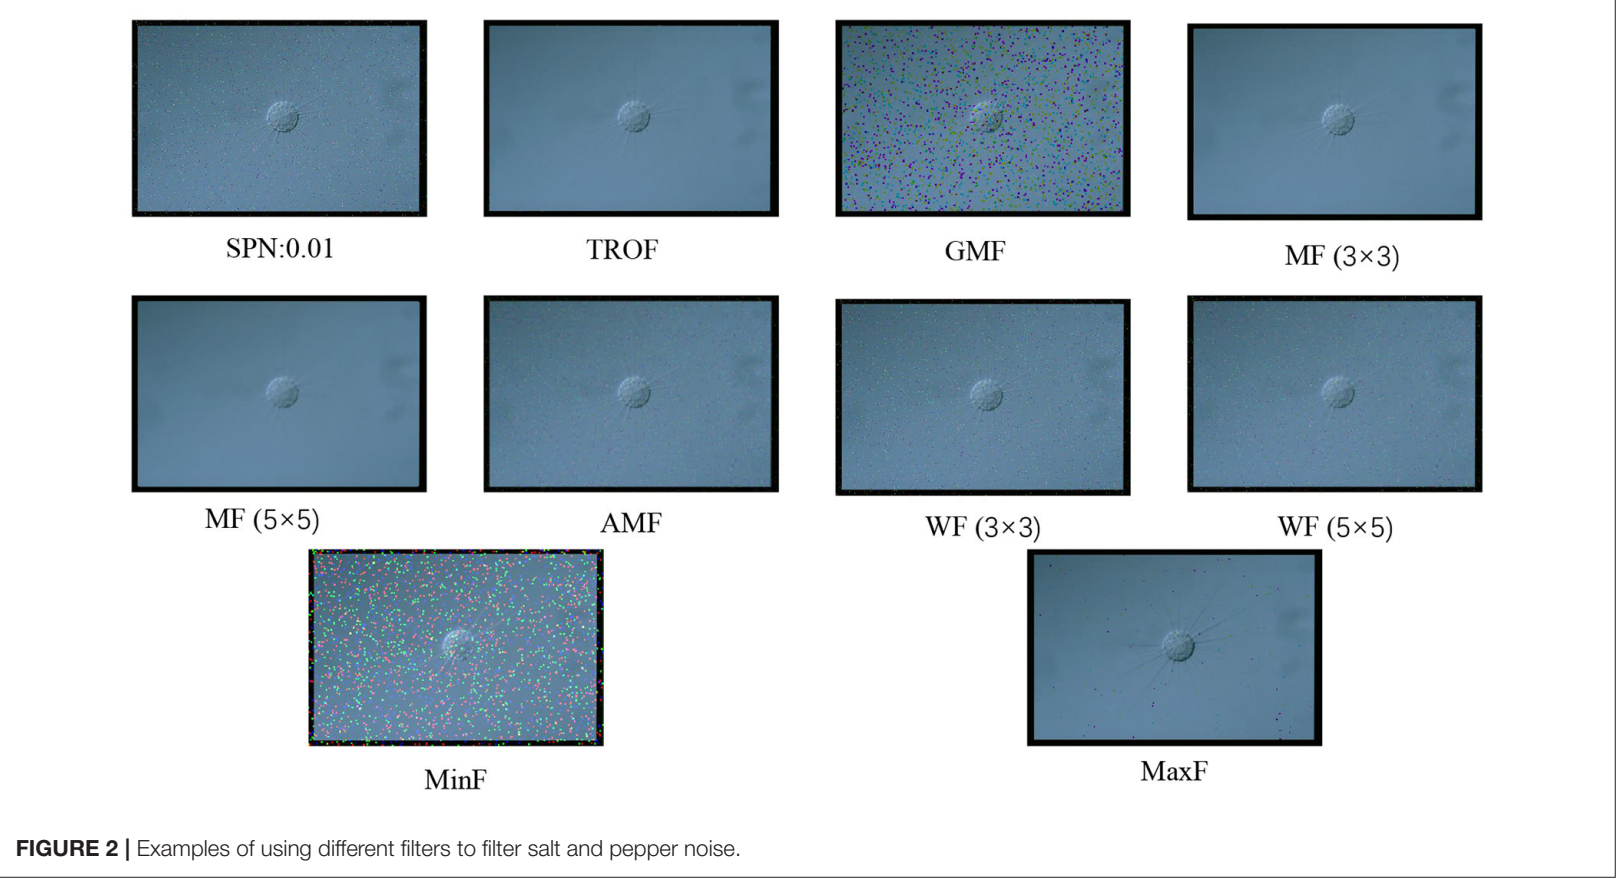

**Therefore, we used the SPN with a value of 0.01 in combination with the TROF filter to perform Noise Addition and Denoising Method processing on the images.**

In [7]:
# Import necessary libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.restoration import denoise_tv_chambolle

In [9]:
# Set base folder paths
base_folder = '../EMDS-6/EMDS5-Original'
output_folder = 'EMDS5-Denoised-Trof'

In [17]:
# Create output folder
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [43]:
# Define a function to add salt and pepper noise
def add_spn_noise(image, density):
    rows, cols = image.shape
    # Calculate the number of salt and pepper noise pixels
    num_salt = np.ceil(density * image.size * 0.5).astype(int)
    num_pepper = np.ceil(density * image.size * 0.5).astype(int)

    # Add salt noise
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    image[coords[0], coords[1]] = 255

    # Add pepper noise
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    image[coords[0], coords[1]] = 0
    return image

In [45]:
# Define a function to use the trof filter
def trof_filter(image, window_size=3):
    pad_size = window_size // 2
    padded_image = np.pad(image, pad_size, mode='reflect')
    height, width = image.shape
    filtered_image = np.zeros_like(image)
    for y in range(height):
        for x in range(width):
            window = padded_image[y:y + window_size, x:x + window_size]
            sorted_window = np.sort(window, axis=None)
            middle_index = (window_size * window_size - 1) // 2
            filtered_image[y, x] = sorted_window[middle_index]
    return filtered_image

In [23]:
# Process images for each class
for class_folder in os.listdir(base_folder):
    class_path = os.path.join(base_folder, class_folder)
    if os.path.isdir(class_path):
        # Create output subfolder
        output_class_folder = os.path.join(output_folder, class_folder)
        if not os.path.exists(output_class_folder):
            os.makedirs(output_class_folder)
            
        # Get 800 images of each class
        image_files = [f for f in os.listdir(class_path) if f.endswith('.png')][:800]
        
        for image_file in image_files:
            try:
                # Read image and convert to grayscale
                image_path = os.path.join(class_path, image_file)
                image = cv2.imread(image_path)
                # Convert BGR image to grayscale
                gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                
                # Add SPN noise
                noisy_image = add_spn_noise(gray_image.copy(), 0.01)
                
                # Apply trof filter
                denoised_image = trof_filter(noisy_image, window_size=3)
                
                # Save processed image
                output_path = os.path.join(output_class_folder, image_file)
                cv2.imwrite(output_path, denoised_image)
                
            except Exception as e:
                print(f"Error processing image {image_file}: {e}")

print("Image processing completed!") 

Image processing completed!
